In [63]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [64]:
filename = "./solutions/debug/Crippa_1h_TotalRefreezing_icegradient.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
W = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(Q)
T_i = Function(W)
T_w = Function(W)
p = Parameter(domain)

In [65]:
len(data_Annika["h_w"])

3

In [66]:
interval = data_Annika["saving_interval"]
t_obs = -1
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)

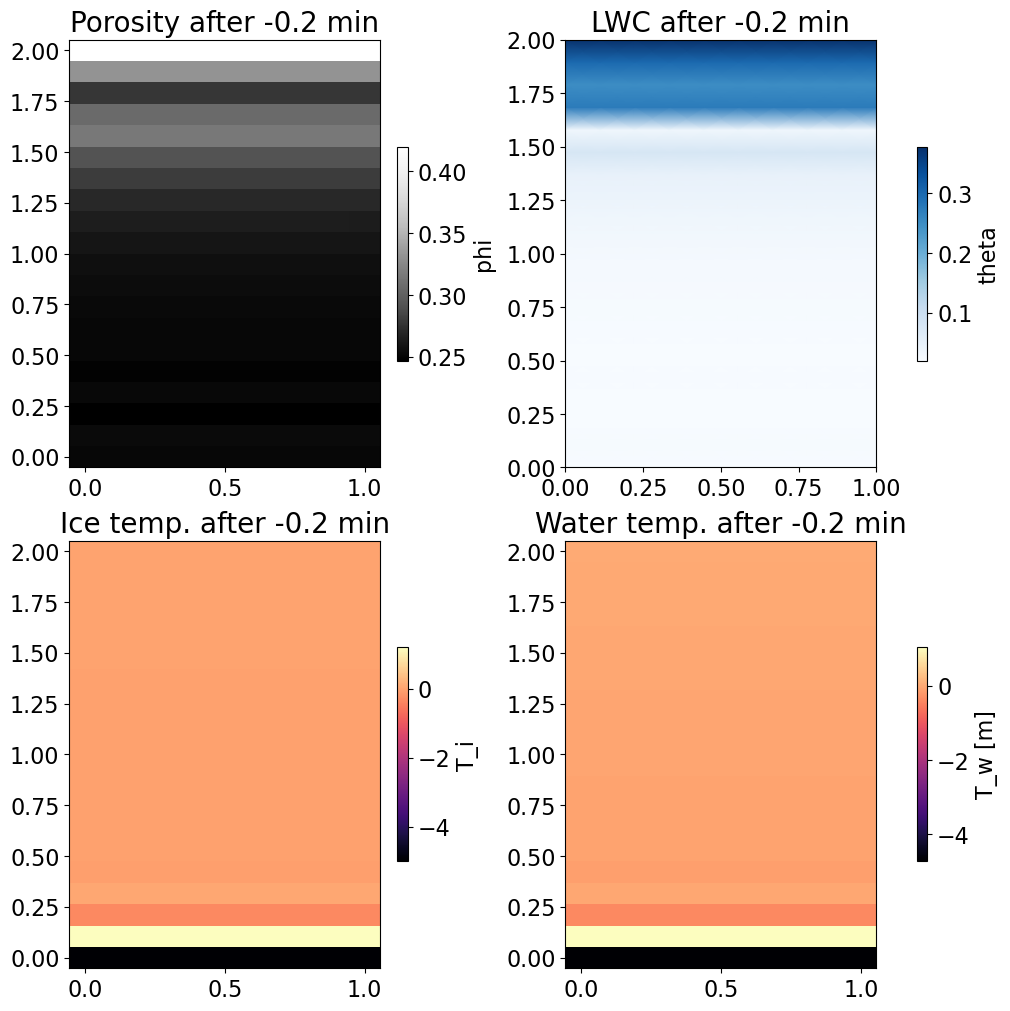

In [67]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, porosity, cmap="Greys_r")
ax[0,0].set_title(f"Porosity after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("phi")

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues", shading="gouraud")
ax[0,1].set_title(f"LWC after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("theta")

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")

In [57]:
porosity

array([[0.30492374, 0.3049235 , 0.30492347, 0.30492375, 0.30492352,
        0.30492383, 0.30492341, 0.30492347, 0.30492377, 0.30492339],
       [0.30528538, 0.305286  , 0.30528539, 0.30528579, 0.30528611,
        0.30528527, 0.3052859 , 0.30528677, 0.30528514, 0.30528583],
       [0.30505428, 0.30505394, 0.30505467, 0.30505471, 0.30505468,
        0.30505462, 0.30505487, 0.30505406, 0.30505371, 0.30505361],
       [0.30517299, 0.3051725 , 0.30517331, 0.30517359, 0.30517301,
        0.30517371, 0.30517333, 0.3051727 , 0.30517414, 0.30517253],
       [0.30511657, 0.30511711, 0.30511718, 0.30511738, 0.30511744,
        0.30511712, 0.30511716, 0.30511826, 0.30511841, 0.30511758],
       [0.30514127, 0.30514089, 0.30514159, 0.30514157, 0.30514155,
        0.3051418 , 0.30514113, 0.30514133, 0.30514201, 0.30514103],
       [0.30513215, 0.3051322 , 0.30513268, 0.30513277, 0.30513266,
        0.3051328 , 0.30513255, 0.30513294, 0.30513337, 0.30513244],
       [0.30513266, 0.30513255, 0.3051330

In [21]:
2760/60

46.0